# M1A7 - Fundamentos de Filtros Espaciais e Convoluções

Na aula de hoje vamos aprender como fazer convoluções utilizando [OpenCV](https://opencv.org/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Convoluções
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [16]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable


Importar as bibliotecas e Ler Imagens do Disco

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [18]:
image = cv2.imread("../assets/bahia.jpeg")

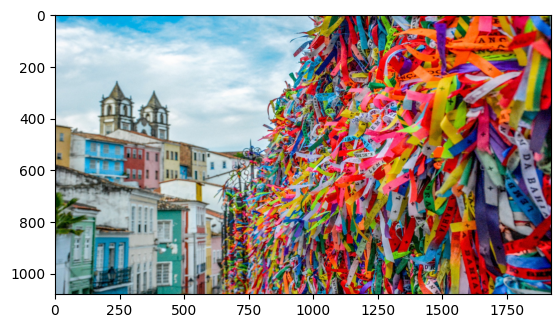

In [19]:
plt.imshow(cv2.cvtColor(image, 4))  # 4 = BGR2RGB

## Convoluções

Para realizar uma convolução é necessário definir primeiro um kernel.

In [20]:
x_canny = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]])
y_canny = np.array([[-1, -2, -1],[0, 0, 0], [1, 2, 1]])

sharp = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])

print(f"x canny kernel:\n{x_canny}")

print(f"y canny kernel:\n{y_canny}")

print(f"sharp kernel:\n{sharp}")

x canny kernel:
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]
y canny kernel:
[[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]
sharp kernel:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]


Agora vamos aplicar esses kernels e observar como eles modificam as imagens.

Para aplicar podemos utilizar a função `cv2.filter2D` para convoluir a imagens com os kernels que fizemos.

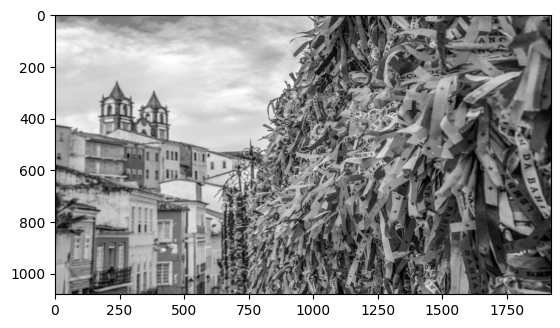

In [21]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap="gray")

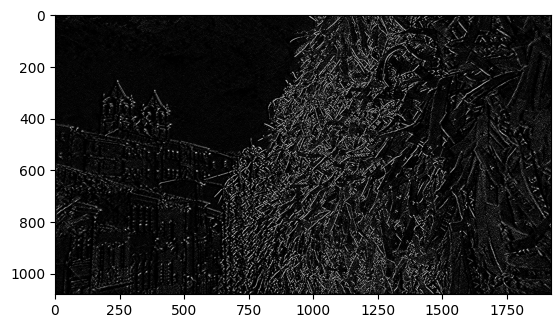

In [22]:
image_canny = cv2.filter2D(gray, -1, x_canny)
image_canny = cv2.filter2D(image_canny, -1, y_canny)
plt.imshow(image_canny, cmap="gray")

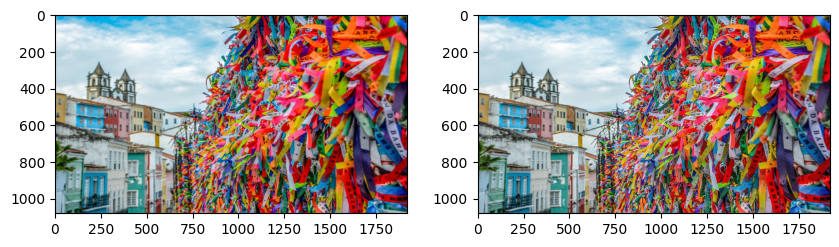

In [23]:
image_sharp = cv2.filter2D(image, -1, sharp)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[1].imshow(cv2.cvtColor(image_sharp, cv2.COLOR_BGR2RGB))
plt.show()

E assim terminamos a prática de hoje.

## Próximos Passos e Referências

Nas próximas práticas iremos avançar ainda mais no mundo de Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opicional)

- [x] Leia a outra imagem do arquivo `rio.jpeg` e rode todos os comandos.
- [x] Tente alterar os valores nos kernels e veja como a alteração reflete na imagem.

### Atividade 1 — rio.jpeg com todos os filtros

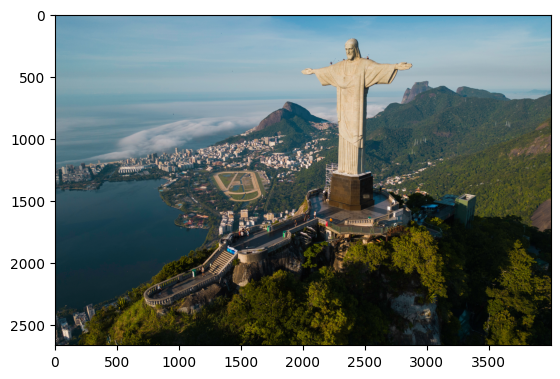

In [24]:
rio = cv2.imread("../assets/rio.jpeg")
plt.imshow(cv2.cvtColor(rio, 4))  # 4 = BGR2RGB

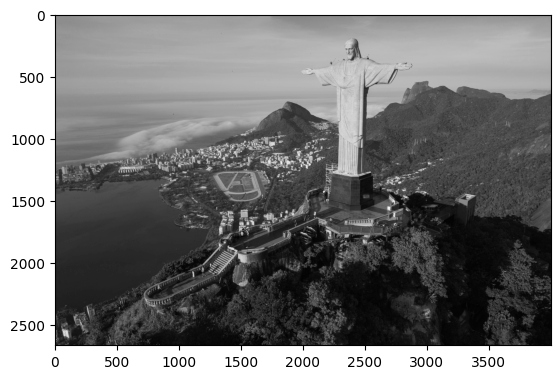

In [25]:
gray_rio = cv2.cvtColor(rio, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_rio, cmap="gray")

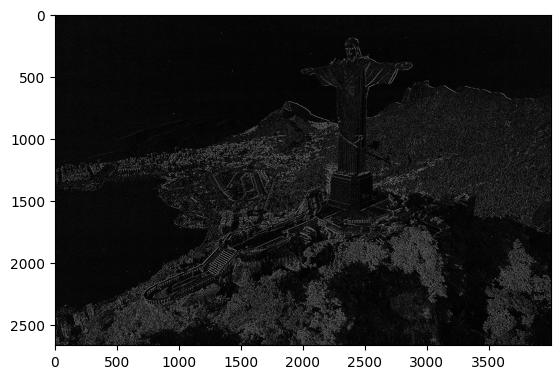

In [26]:
rio_canny = cv2.filter2D(gray_rio, -1, x_canny)
rio_canny = cv2.filter2D(rio_canny, -1, y_canny)
plt.imshow(rio_canny, cmap="gray")

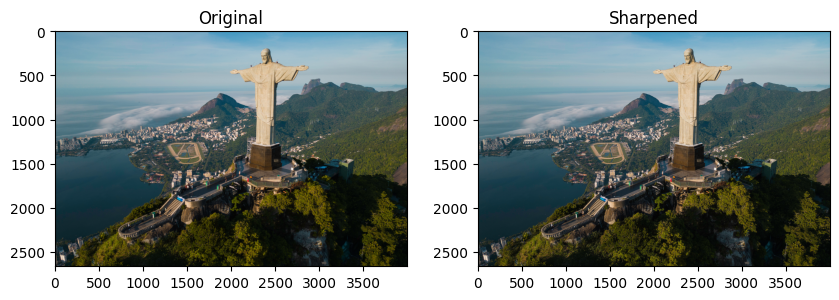

In [27]:
rio_sharp = cv2.filter2D(rio, -1, sharp)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(cv2.cvtColor(rio, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[1].imshow(cv2.cvtColor(rio_sharp, cv2.COLOR_BGR2RGB))
axes[1].set_title("Sharpened")
plt.show()

### Atividade 2 — Modificação de kernels

In [28]:
# Blur: suaviza a imagem (reduz ruído)
blur_kernel = np.array([[1, 2, 1],
                        [2, 4, 2],
                        [1, 2, 1]], dtype=np.float32) / 16

# Emboss: realça relevo/profundidade
emboss_kernel = np.array([[-2, -1, 0],
                           [-1,  1, 1],
                           [ 0,  1, 2]])

# Detecção de bordas mais forte (Laplaciano)
laplacian_kernel = np.array([[-1, -1, -1],
                              [-1,  8, -1],
                              [-1, -1, -1]])

print("Blur kernel:\n", blur_kernel)
print("\nEmboss kernel:\n", emboss_kernel)
print("\nLaplacian kernel:\n", laplacian_kernel)

Blur kernel:
 [[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]

Emboss kernel:
 [[-2 -1  0]
 [-1  1  1]
 [ 0  1  2]]

Laplacian kernel:
 [[-1 -1 -1]
 [-1  8 -1]
 [-1 -1 -1]]


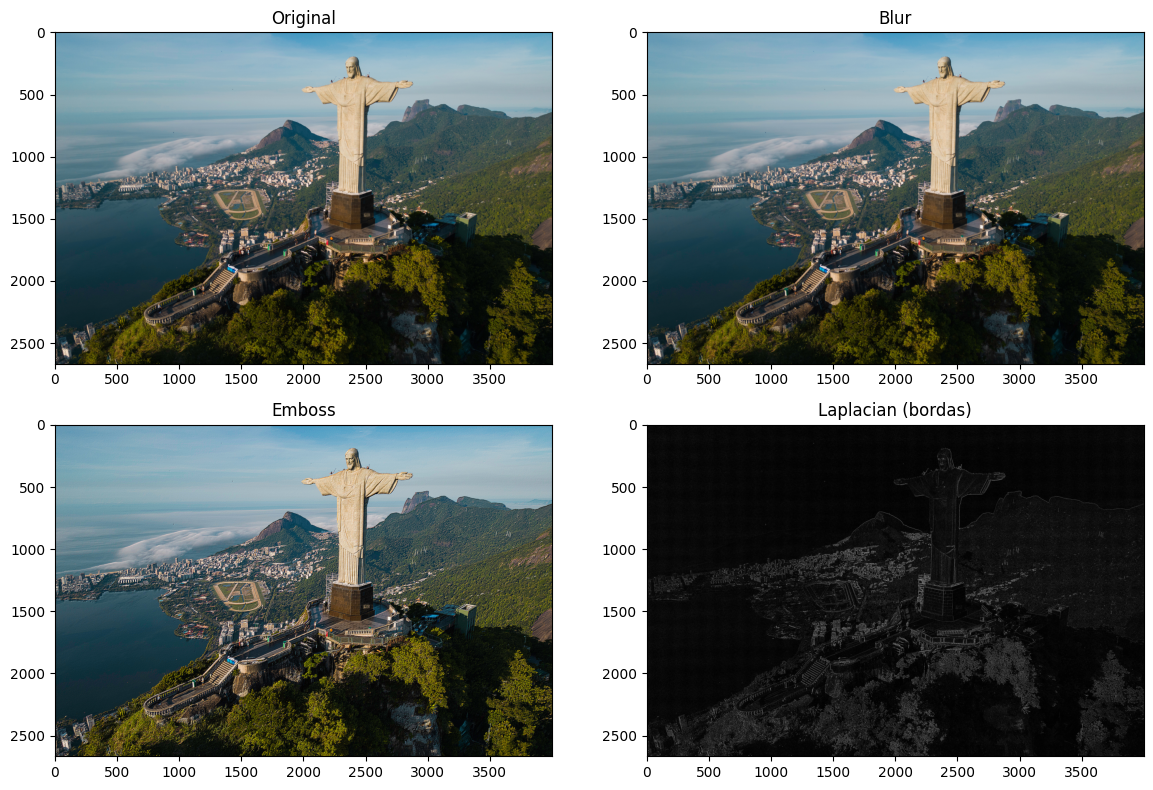

In [32]:
image_blur = cv2.filter2D(rio, -1, blur_kernel)
image_emboss = cv2.filter2D(rio, -1, emboss_kernel)
image_laplacian = cv2.filter2D(gray_rio, -1, laplacian_kernel)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))


axes[0,0].imshow(cv2.cvtColor(rio, cv2.COLOR_BGR2RGB))
axes[0,0].set_title("Original")

axes[0,1].imshow(cv2.cvtColor(image_blur, cv2.COLOR_BGR2RGB))
axes[0,1].set_title("Blur")

axes[1,0].imshow(cv2.cvtColor(image_emboss, cv2.COLOR_BGR2RGB))
axes[1,0].set_title("Emboss")

axes[1,1].imshow(image_laplacian, cmap="gray")
axes[1,1].set_title("Laplacian (bordas)")

plt.tight_layout()
plt.show()